# M5 aggregate — forecast accuracy analysis

This notebook is the readable spec behind `tests/test_m5_accuracy.py` (issue #59): every section
below mirrors that module step for step — same fixture, same split, same prior, same NUTS
configuration — so a reader can see what the accuracy guard actually watches instead of taking
three asserted numbers on faith. When one changes, change both.

Sections 2 through 6 run entirely off the committed
`bunobee.datasets.load_m5_aggregate()` fixture, so anyone with a clone can execute the interesting
part without the 980 MB raw M5 download. Section 1's item-store contrast is the only part that
needs the raw dump, and skips cleanly when it is absent.

In [ ]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from bunobee.datasets import load_m5_aggregate
from bunobee.models.ssp import build_forecast_design, forecast_ssp, transform_to_ekf_st
from bunobee.models.ssp.plotting import plot_states
from bunobee.regression import make_peridoic_dummies
from bunobee.utils import summarize_idata

plt.rcParams["figure.dpi"] = 80

In [ ]:
# Repo layout: this notebook lives at playground/m5_prototype/.
ROOT = Path.cwd().resolve().parents[1]
RAW_DIR = ROOT / "playground" / "resource" / "m5-forecasting-accuracy"

SERIES = [
    "CA_FOODS",
    "CA_HOBBIES",
    "CA_HOUSEHOLD",
    "TOTAL",
    "TX_FOODS",
    "TX_HOBBIES",
    "TX_HOUSEHOLD",
    "WI_FOODS",
    "WI_HOBBIES",
    "WI_HOUSEHOLD",
]
N_SERIES = len(SERIES)

# Window and panel shape — matches tests/test_m5_accuracy.py exactly.
N_STEPS = 728
HORIZON = 28
N_DATES = N_STEPS + HORIZON

# Design: [intercept | 6 weekly dummies], no covariates.
PERIOD = 7
N_DUMMIES = PERIOD - 1
N_STATES = 1 + N_DUMMIES
WEEKLY_SPEC = {"columns": slice(1, PERIOD), "period": PERIOD, "drop_first": True}
STATE_LABELS = ["level"] + [f"dow_{i}" for i in range(1, PERIOD)]

# On the mean-normalized scale every state is linear, so nothing is exponentiated.
EXPONENT = 1.0
POSITIVITY = np.zeros(N_STATES, dtype=bool)

# Natural-scale prior.
A0 = np.concatenate([[1.0], np.zeros(N_DUMMIES)])
P0_DIAG = np.concatenate([[0.25], np.full(N_DUMMIES, 0.05)])
SIGMA_Q_SCALE = np.concatenate([[0.05], np.full(N_DUMMIES, 0.005)])

# NUTS budget — identical to the test module.
NUM_WARMUP = 100
NUM_SAMPLES = 100
NUM_CHAINS = 2
MAX_TREE_DEPTH = 5
FORECAST_SEED = 0
NAIVE_PERIOD = 7

# Committed thresholds from tests/test_m5_accuracy.py — section 6 checks this run reproduces them.
PANEL_MAPE_MAX = 14.0
SERIES_MAPE_MAX = 22.0
MAX_NAIVE_RATIO = 1.0

## 1. Aggregation and the density claim

Raw M5 item-store series are intermittent and zero-inflated — MAPE on a series that spends half
its life at zero means nothing. Summing to `state_id x cat_id` (9 series) plus a national `TOTAL`
(10 series total) gives a panel that is dense and strictly positive everywhere, which is what makes
it possible to score at all.

In [ ]:
panel = load_m5_aggregate()
wide = panel.pivot(index="date", columns="series_id", values="sales").reindex(columns=SERIES)

density = pd.DataFrame(
    {
        "min": wide.min(),
        "zero_count": (wide == 0).sum(),
        "cv": wide.std() / wide.mean(),
    }
).loc[SERIES]
density

,min,zero_count,cv
series_id,,,
CA_FOODS,6005,0,0.180840
CA_HOBBIES,647,0,0.166918
CA_HOUSEHOLD,1765,0,0.216471
TOTAL,21844,0,0.168667
TX_FOODS,3829,0,0.170247
TX_HOBBIES,521,0,0.189363
TX_HOUSEHOLD,1398,0,0.188977
WI_FOODS,4110,0,0.220141
WI_HOBBIES,283,0,0.220229


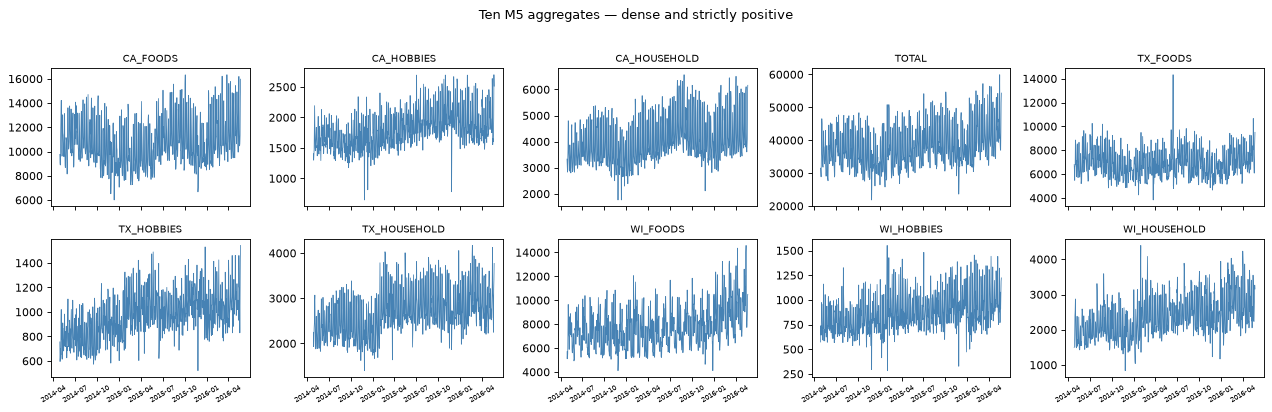

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(16, 5), sharex=True)
for ax, name in zip(axes.flat, SERIES):
    ax.plot(wide.index, wide[name], linewidth=0.7, color="steelblue")
    ax.set_title(name, fontsize=9)
    ax.tick_params(axis="x", labelsize=6, rotation=30)
fig.suptitle("Ten M5 aggregates — dense and strictly positive", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
if RAW_DIR.exists():
    import sys

    sys.path.insert(0, str(ROOT / "playground" / "m5_prototype"))
    from m5_preprocess import build_m5_dataset

    raw_ds = build_m5_dataset(RAW_DIR)
    observed = np.isin(np.asarray(raw_ds["split"].values), ("train", "validation"))
    raw_sales = np.asarray(raw_ds["sales"].values)[:, observed]
    raw_dates = pd.DatetimeIndex(np.asarray(raw_ds["date"].values)[observed])

    # The most intermittent item-store series: fewest nonzero observed days.
    nnz = (raw_sales > 0).sum(axis=1)
    worst_idx = int(np.argmin(nnz))
    worst_id = str(raw_ds["series_id"].values[worst_idx])

    fig, axes = plt.subplots(1, 2, figsize=(13, 3.2))
    axes[0].plot(raw_dates, raw_sales[worst_idx], linewidth=0.6, color="firebrick")
    axes[0].set_title(f"item-store {worst_id}\n({int(nnz[worst_idx])}/{len(raw_dates)} nonzero days)", fontsize=9)
    axes[1].plot(wide.index, wide["TOTAL"], linewidth=0.7, color="steelblue")
    axes[1].set_title("state x cat aggregate: TOTAL", fontsize=9)
    for ax in axes:
        ax.tick_params(axis="x", labelsize=7, rotation=30)
    fig.suptitle("Why item-store is rejected: intermittent vs. dense", y=1.05)
    plt.tight_layout()
    plt.show()
else:
    print(
        f"raw M5 dump not found at {RAW_DIR} (980 MB, gitignored) -- skipping the item-store "
        "contrast. The density table above, computed from the committed fixture alone, already "
        "shows every aggregate is zero-free."
    )

raw M5 dump not found at /home/user/bunobee/playground/resource/m5-forecasting-accuracy (980 MB, gitignored) -- skipping the item-store contrast. The density table above, computed from the committed fixture alone, already shows every aggregate is zero-free.


## 2. Split and normalization

The last 28 days are held out; the remaining 728 days train the model. Every series is normalized
by its own training-window mean before fitting, so the ten series — which run at very different
scales — share one prior.

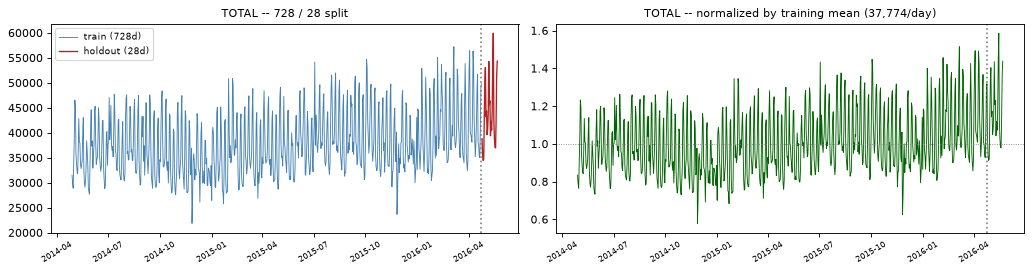

In [ ]:
dates = wide.index
train_dates, holdout_dates = dates[:N_STEPS], dates[N_STEPS:]

demo_series = "TOTAL"
y_demo = wide[demo_series].to_numpy(dtype=float)
demo_scale = y_demo[:N_STEPS].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].plot(train_dates, y_demo[:N_STEPS], color="steelblue", linewidth=0.8, label="train (728d)")
axes[0].plot(holdout_dates, y_demo[N_STEPS:], color="firebrick", linewidth=1.2, label="holdout (28d)")
axes[0].axvline(train_dates[-1], color="grey", linestyle=":")
axes[0].set_title(f"{demo_series} -- 728 / 28 split", fontsize=10)
axes[0].legend(fontsize=8)

axes[1].plot(dates, y_demo / demo_scale, color="darkgreen", linewidth=0.8)
axes[1].axhline(1.0, color="grey", linestyle=":", linewidth=0.8)
axes[1].axvline(train_dates[-1], color="grey", linestyle=":")
axes[1].set_title(f"{demo_series} -- normalized by training mean ({demo_scale:,.0f}/day)", fontsize=10)

for ax in axes:
    ax.tick_params(axis="x", labelsize=7, rotation=30)
plt.tight_layout()
plt.show()

## 3. Fit

Same prior and NUTS configuration as `tests/test_m5_accuracy.py::_ekf_prior` /
`_run_nuts`: a shared-state extended Kalman filter likelihood with per-series observation noise
and per-state process noise, both Beta-distributed on the natural scale.

In [ ]:
def build_design(n_all: int) -> np.ndarray:
    dummies = np.asarray(make_peridoic_dummies(n_all, period=PERIOD, drop_first=True), dtype=float)
    intercept = np.ones((n_all, N_SERIES, 1))
    dummies_b = np.broadcast_to(dummies[:, None, :], (n_all, N_SERIES, N_DUMMIES))
    return np.concatenate([intercept, dummies_b], axis=-1)


def ekf_prior() -> xr.Dataset:
    prior = xr.Dataset(
        {
            "a0": (("state",), A0),
            "P0": (("state", "state_dual"), np.diag(P0_DIAG)),
            "positivity": (("state",), POSITIVITY),
            "sigma_q_alpha_prior": (("state",), np.full(N_STATES, 2.0)),
            "sigma_q_beta_prior": (("state",), np.full(N_STATES, 10.0)),
            "sigma_q_scale_prior": (("state",), SIGMA_Q_SCALE),
        }
    ).assign_attrs({"sigma_q_family": "beta"})
    return transform_to_ekf_st(prior, exponent=EXPONENT)


def run_nuts(prior_ekf: xr.Dataset, y_train: np.ndarray, Z_train: np.ndarray) -> xr.Dataset:
    import jax.numpy as jnp
    import numpyro
    from jax import random
    from numpyro import distributions as dist
    from numpyro.infer import MCMC, NUTS

    from bunobee.models.ssp.kalman_1d_st_ekf import kalman_filter_1d_ekf_st

    a0 = jnp.asarray(prior_ekf["a0"].values)
    P0 = jnp.asarray(prior_ekf["P0"].values)
    positivity_j = jnp.asarray(POSITIVITY)
    sigma_q_alpha = jnp.asarray(prior_ekf["sigma_q_alpha_prior"].values)
    sigma_q_beta = jnp.asarray(prior_ekf["sigma_q_beta_prior"].values)
    sigma_q_scale = jnp.asarray(prior_ekf["sigma_q_scale_prior"].values)
    sdy = jnp.asarray(y_train.std(axis=0))
    Z_j, y_j = jnp.asarray(Z_train), jnp.asarray(y_train)

    def model():
        with numpyro.plate("series", N_SERIES):
            sigma_h_raw = numpyro.sample("sigma_h_raw", dist.Beta(2.0, 10.0))
        sigma_h = numpyro.deterministic("sigma_h", sigma_h_raw * sdy)
        sigma_q_raw = numpyro.sample("sigma_q_raw", dist.Beta(sigma_q_alpha, sigma_q_beta))
        sigma_q = numpyro.deterministic("sigma_q", sigma_q_raw * sigma_q_scale)
        lp, at, _, _, _, _ = kalman_filter_1d_ekf_st(
            a0=a0,
            P0=P0,
            Z=Z_j,
            sigma_h=sigma_h,
            sigma_q=sigma_q,
            y=y_j,
            logp=True,
            exponent=EXPONENT,
            positivity=positivity_j,
        )
        numpyro.factor("lp", lp)
        numpyro.deterministic("at", at)

    mcmc = MCMC(
        NUTS(model, max_tree_depth=MAX_TREE_DEPTH),
        num_warmup=NUM_WARMUP,
        num_samples=NUM_SAMPLES,
        num_chains=NUM_CHAINS,
        chain_method="sequential",
        progress_bar=False,
    )
    mcmc.run(random.PRNGKey(0))
    samples = mcmc.get_samples(group_by_chain=True)

    return xr.Dataset(
        {
            "at": (("chain", "draw", "step", "state"), np.asarray(samples["at"])),
            "sigma_q": (("chain", "draw", "state"), np.asarray(samples["sigma_q"])),
            "sigma_h": (("chain", "draw", "series"), np.asarray(samples["sigma_h"])),
            "positivity": (("state",), POSITIVITY),
        }
    ).assign_attrs({"exponent": EXPONENT})

In [ ]:
y_all = wide.to_numpy(dtype=float)  # (N_DATES, N_SERIES), columns already in SERIES order
scale = y_all[:N_STEPS].mean(axis=0)
y = y_all / scale

Z_all = build_design(N_DATES)
Z_train, y_train = Z_all[:N_STEPS], y[:N_STEPS]

idata = run_nuts(ekf_prior(), y_train, Z_train)
print(f"posterior draws: {idata.sizes['chain']} chains x {idata.sizes['draw']} samples")

posterior draws: 2 chains x 100 samples


In [ ]:
# Diagnostics the test throws away: r_hat and ESS on the sampled scales, and the filtered states.
summarize_idata(idata[["sigma_q", "sigma_h"]])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_q[0],0.049,0.000,0.048,0.049,0.0,0.0,242.0,152.0,1.02
sigma_q[1],0.001,0.000,0.000,0.002,0.0,0.0,184.0,57.0,1.01
sigma_q[2],0.001,0.001,0.000,0.002,0.0,0.0,118.0,78.0,1.02
sigma_q[3],0.001,0.001,0.000,0.003,0.0,0.0,166.0,94.0,1.01
sigma_q[4],0.002,0.001,0.000,0.003,0.0,0.0,147.0,114.0,0.99
sigma_q[5],0.003,0.000,0.002,0.004,0.0,0.0,309.0,219.0,1.00
sigma_q[6],0.003,0.001,0.002,0.004,0.0,0.0,238.0,120.0,1.02
sigma_h[0],0.071,0.002,0.067,0.075,0.0,0.0,192.0,124.0,1.01
sigma_h[1],0.109,0.003,0.104,0.115,0.0,0.0,232.0,122.0,1.00
sigma_h[2],0.093,0.002,0.089,0.097,0.0,0.0,185.0,128.0,1.00


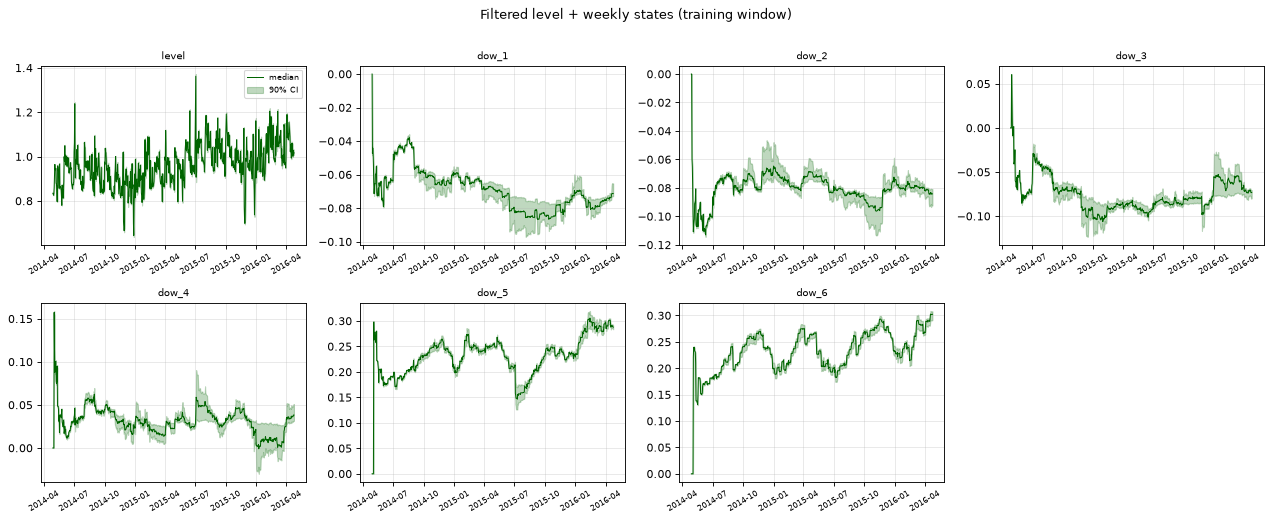

In [ ]:
fig, axes = plot_states(
    idata,
    dates=train_dates,
    state_labels=STATE_LABELS,
    states_key="at",
    title="Filtered level + weekly states (training window)",
)
plt.show()

## 4. Forecast

`build_forecast_design` continues the weekly cycle 28 days past the training window;
`forecast_ssp` draws from the posterior over that future design.

In [ ]:
Z_future = build_forecast_design(Z_train, HORIZON, periodic=WEEKLY_SPEC)
out = forecast_ssp(idata, Z_future, noise_embed=False, seed=FORECAST_SEED)
forecast_samples = out["forecast_samples"].values  # (n_posterior, HORIZON, N_SERIES), normalized scale

forecast = np.median(forecast_samples, axis=0) * scale  # point forecast, un-normalized
truth = y_all[N_STEPS:]
naive = y_all[:N_STEPS][-NAIVE_PERIOD:][np.arange(HORIZON) % NAIVE_PERIOD]

# In-sample fit, for context in the fan chart below: mu[t, s] = Z_train[t, s, :] . at[t, :].
at_samples = idata["at"].stack(sample=("chain", "draw")).transpose("sample", ...).values
mu_train = np.median(np.einsum("tsk,ntk->nts", Z_train, at_samples), axis=0) * scale

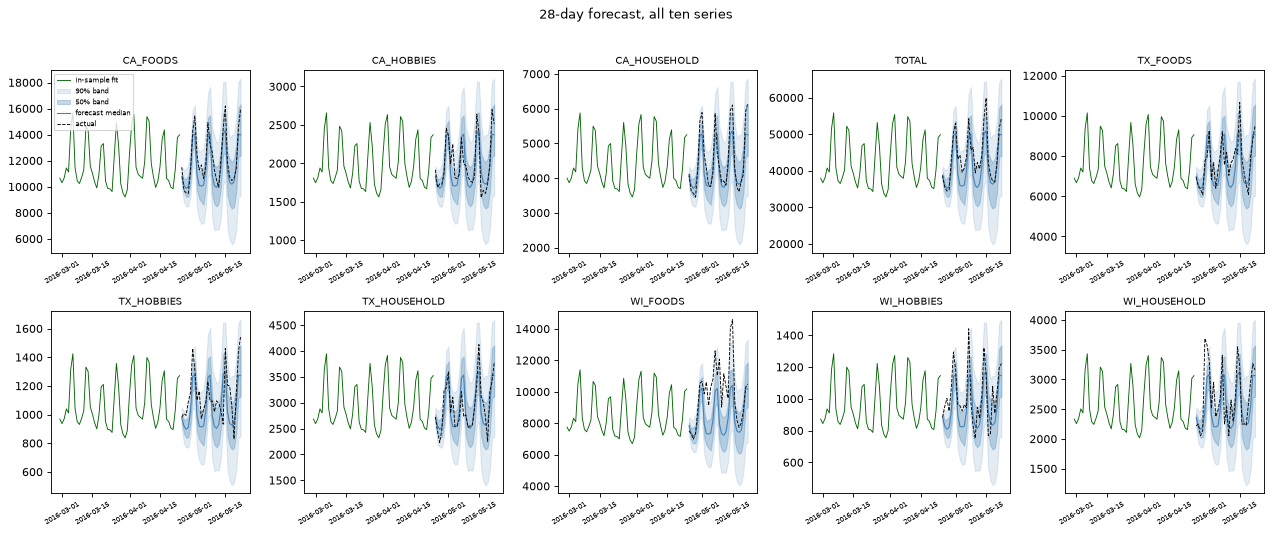

In [ ]:
q05, q25, q50, q75, q95 = np.quantile(forecast_samples, [0.05, 0.25, 0.5, 0.75, 0.95], axis=0) * scale
context_days = 8 * PERIOD

fig, axes = plt.subplots(2, 5, figsize=(16, 6.5), sharex=False)
for i, (ax, name) in enumerate(zip(axes.flat, SERIES)):
    ax.plot(train_dates[-context_days:], mu_train[-context_days:, i], color="darkgreen", linewidth=0.8, label="in-sample fit")
    ax.fill_between(holdout_dates, q05[:, i], q95[:, i], color="steelblue", alpha=0.15, label="90% band")
    ax.fill_between(holdout_dates, q25[:, i], q75[:, i], color="steelblue", alpha=0.30, label="50% band")
    ax.plot(holdout_dates, q50[:, i], color="steelblue", linewidth=1.0, label="forecast median")
    ax.plot(holdout_dates, truth[:, i], color="black", linewidth=0.8, linestyle="--", label="actual")
    ax.set_title(name, fontsize=9)
    ax.tick_params(axis="x", labelsize=6, rotation=30)
axes.flat[0].legend(fontsize=6, loc="upper left")
fig.suptitle("28-day forecast, all ten series", y=1.02)
plt.tight_layout()
plt.show()

## 5. Accuracy analysis

Model MAPE against a seasonal-naive baseline ("same weekday last week", carried across the
horizon), per series and as a panel mean, plus an error-by-horizon breakdown the test does not
compute: it separates a level error at `h = 1` from drift that accumulates over the horizon.

In [ ]:
def mape(truth: np.ndarray, pred: np.ndarray) -> np.ndarray:
    return 100.0 * np.mean(np.abs(truth - pred) / np.abs(truth), axis=0)


mape_model = mape(truth, forecast)
mape_naive = mape(truth, naive)
ratio = mape_model / mape_naive

table = pd.DataFrame({"series": SERIES, "MAPE_model%": mape_model, "MAPE_naive%": mape_naive, "ratio": ratio})
table.loc[len(table)] = ["panel mean", mape_model.mean(), mape_naive.mean(), mape_model.mean() / mape_naive.mean()]
table

,series,MAPE_model%,MAPE_naive%,ratio
0,CA_FOODS,6.243361,6.699036,0.931979
1,CA_HOBBIES,6.204566,8.377566,0.740617
2,CA_HOUSEHOLD,6.150321,5.279087,1.165035
3,TOTAL,7.406917,8.308903,0.891443
4,TX_FOODS,7.883356,9.697490,0.812927
5,TX_HOBBIES,11.956384,12.019362,0.994760
6,TX_HOUSEHOLD,6.860515,10.721757,0.639869
7,WI_FOODS,14.271833,13.186387,1.082316
8,WI_HOBBIES,10.421315,8.787398,1.185939
9,WI_HOUSEHOLD,9.826572,7.985682,1.230524


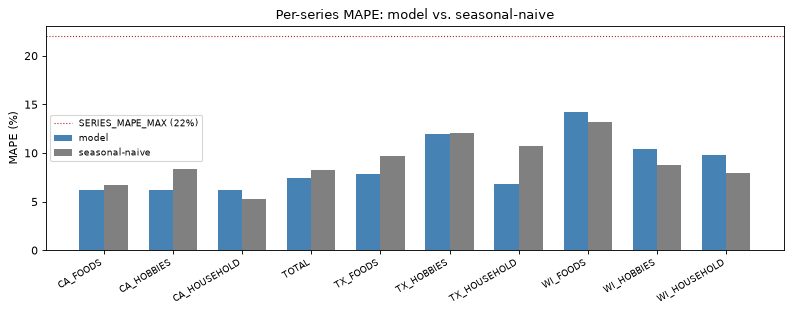

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(N_SERIES)
width = 0.35
ax.bar(x - width / 2, mape_model, width, label="model", color="steelblue")
ax.bar(x + width / 2, mape_naive, width, label="seasonal-naive", color="grey")
ax.axhline(SERIES_MAPE_MAX, color="firebrick", linestyle=":", linewidth=1, label=f"SERIES_MAPE_MAX ({SERIES_MAPE_MAX:.0f}%)")
ax.set_xticks(x)
ax.set_xticklabels(SERIES, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("MAPE (%)")
ax.set_title("Per-series MAPE: model vs. seasonal-naive")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

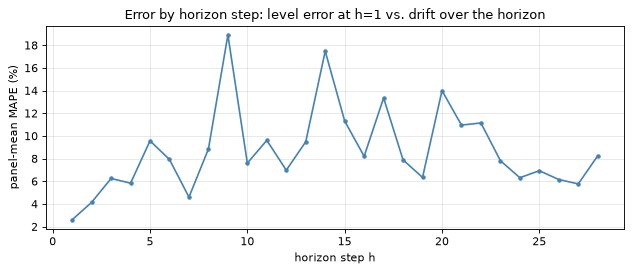

In [ ]:
abs_pct_err = 100.0 * np.abs(truth - forecast) / np.abs(truth)  # (HORIZON, N_SERIES)
mape_by_h = abs_pct_err.mean(axis=1)  # panel mean at each horizon step

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(np.arange(1, HORIZON + 1), mape_by_h, marker="o", markersize=3, color="steelblue")
ax.set_xlabel("horizon step h")
ax.set_ylabel("panel-mean MAPE (%)")
ax.set_title("Error by horizon step: level error at h=1 vs. drift over the horizon")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Threshold calibration

Where the three constants in `tests/test_m5_accuracy.py` come from: the two absolute ceilings
carry 50% relative headroom over the calibrated value (rounded up), and `MAX_NAIVE_RATIO` is fixed
at 1.0 -- the model must beat "same weekday last week", not merely avoid a large absolute error.

In [ ]:
panel_mape_model = float(mape_model.mean())
panel_mape_naive = float(mape_naive.mean())
panel_ratio = panel_mape_model / panel_mape_naive
worst_i = int(np.argmax(mape_model))
worst_series_mape = float(mape_model[worst_i])

suggested_panel_max = float(np.ceil(panel_mape_model * 1.5))
suggested_series_max = float(np.ceil(worst_series_mape * 1.5))

print(f"panel-mean MAPE     : {panel_mape_model:.2f}%")
print(f"seasonal-naive MAPE : {panel_mape_naive:.2f}%")
print(f"panel ratio         : {panel_ratio:.3f}")
print(f"worst series MAPE   : {worst_series_mape:.2f}% ({SERIES[worst_i]})")
print()
print("thresholds to paste into tests/test_m5_accuracy.py (1.5x headroom, rounded up):")
print(f"  PANEL_MAPE_MAX  = {suggested_panel_max:.1f}")
print(f"  SERIES_MAPE_MAX = {suggested_series_max:.1f}")
print(f"  MAX_NAIVE_RATIO = {MAX_NAIVE_RATIO:.1f}  # fixed: the model must beat seasonal-naive")

assert suggested_panel_max == PANEL_MAPE_MAX, "recalibrate: panel ceiling drifted from the committed threshold"
assert suggested_series_max == SERIES_MAPE_MAX, "recalibrate: per-series ceiling drifted from the committed threshold"
assert panel_ratio <= MAX_NAIVE_RATIO, "the healthy fit no longer beats seasonal-naive -- recalibrate before trusting the guard"

panel-mean MAPE     : 8.72%
seasonal-naive MAPE : 9.11%
panel ratio         : 0.958
worst series MAPE   : 14.27% (WI_FOODS)

thresholds to paste into tests/test_m5_accuracy.py (1.5x headroom, rounded up):
  PANEL_MAPE_MAX  = 14.0
  SERIES_MAPE_MAX = 22.0
  MAX_NAIVE_RATIO = 1.0  # fixed: the model must beat seasonal-naive


## 7. What the tripwire catches

Zeroing the weekly block in `Z_future` is the cheapest realistic break: shapes, identities, and
the fit itself all stay valid, only the seasonal continuation is gone -- exactly the class of
regression the rest of the suite lands green on.

In [ ]:
Z_broken = Z_future.copy()
Z_broken[:, :, 1:PERIOD] = 0.0
out_broken = forecast_ssp(idata, Z_broken, noise_embed=False, seed=FORECAST_SEED)
forecast_broken = np.median(out_broken["forecast_samples"].values, axis=0) * scale

mape_broken = mape(truth, forecast_broken)
panel_mape_broken = float(mape_broken.mean())
ratio_broken = panel_mape_broken / panel_mape_naive

print(f"healthy forecast : panel MAPE {panel_mape_model:.2f}%  ratio {panel_ratio:.3f}")
print(f"broken forecast  : panel MAPE {panel_mape_broken:.2f}%  ratio {ratio_broken:.3f}")
verdict = "TRIPS" if ratio_broken > MAX_NAIVE_RATIO else "does NOT trip"
print(f"MAX_NAIVE_RATIO  : {MAX_NAIVE_RATIO:.3f}  -> the broken forecast {verdict} the guard")
assert ratio_broken > MAX_NAIVE_RATIO, "the tripwire did not fire on a forecast with no weekly block"
assert panel_mape_broken > panel_mape_model, "the broken forecast scored no worse than the healthy one"

healthy forecast : panel MAPE 8.72%  ratio 0.958
broken forecast  : panel MAPE 13.54%  ratio 1.487
MAX_NAIVE_RATIO  : 1.000  -> the broken forecast TRIPS the guard


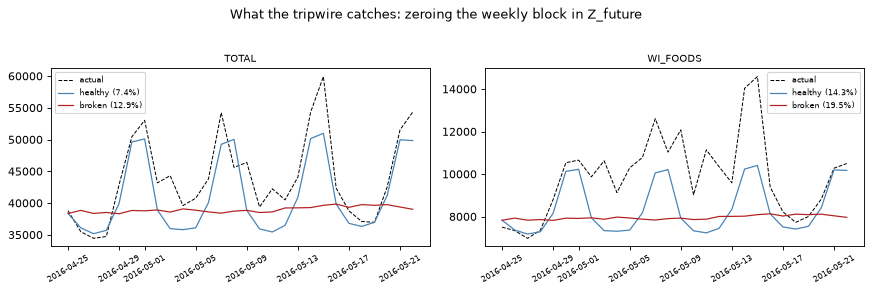

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=False)
for ax, name in zip(axes, ["TOTAL", "WI_FOODS"]):
    i = SERIES.index(name)
    ax.plot(holdout_dates, truth[:, i], color="black", linestyle="--", linewidth=0.9, label="actual")
    ax.plot(holdout_dates, forecast[:, i], color="steelblue", linewidth=1.1, label=f"healthy ({mape_model[i]:.1f}%)")
    ax.plot(holdout_dates, forecast_broken[:, i], color="firebrick", linewidth=1.1, label=f"broken ({mape_broken[i]:.1f}%)")
    ax.set_title(name, fontsize=9)
    ax.tick_params(axis="x", labelsize=7, rotation=30)
    ax.legend(fontsize=7)
fig.suptitle("What the tripwire catches: zeroing the weekly block in Z_future", y=1.03)
plt.tight_layout()
plt.show()